# Seminar 5 - Recurrent Neural Networks

## Part 1. Classification

### Environment Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from tqdm.auto import tqdm, trange
import re

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [ ]:
df = pd.read_csv('/kaggle/input/ai-vs-human-text/AI_Human.csv')
df


,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0
...,...,...
487230,Tie Face on Mars is really just a big misunder...,0.0
487231,The whole purpose of democracy is to create a ...,0.0
487232,I firmly believe that governments worldwide sh...,1.0
487233,I DFN't agree with this decision because a LFT...,0.0


In [ ]:
df.loc[df['generated'] == 0]['text'].sample(random_state=42).values


array(["Do curfews keep teenagers from Getting into trouble? The city council is still currently debating on either adopting the curfew to be at 10 p. m. during the week days or at midnight on the weekends. If teenagers were to be out after the hours selected, it would be considered breaking the law. The laws are choose for many reasons, even if we don't tree with most of them; we have to obey the laws. I believe the city council should adopt the curfew for the minors. When it comes to under ate people in this world we have to be more concerned for their safety, it is best to have curfews. We should consider all the dangerous things Point on in this world.\n\nHave you considered all the things that could happen when your child is out? There is many dangerous things Point on in this world. I'm not saying something will happen but honestly nowadays anything could happen. Without an adults care vision many things could occur. Many minors are band killed or harmed for reasons we don't know

In [ ]:
df.loc[df['generated'] == 1]['text'].sample(random_state=42).values


array([" I believe that online classes and video conferencing are beneficial For students, especially those who Dace challenges such as transportation issues or bullying. In today's world, students often prefer online classes because they can access their education From the comfort OD their own home. This eliminates the distractions and pressures OD the traditional classroom environment, allowing students to work at their own pace and on their own schedule.\n\nFor example, my Friend struggled with transportation issues and Found it difficult to attend classes on time. However, when he started taking online classes, he was able to manage his time more effectively and complete his work without any distractions. Additionally, video conferencing has become an increasingly popular option For students, as it allows them to interact with their teachers and peers in a virtual environment.\n\nOnline classes and video conferencing also provide a Sade and supportive environment For students who h

In [ ]:
df.loc[df['generated'] == 1]['text'].sample(random_state=36).values


array(['Dear Senator,\n\nI write to you as a concerned citizen of our great state regarding the current system we use to elect the President of the United States the Electoral College. The Electoral College, as described by the Office of the Federal Register, is a process that was established in the Constitution as a compromise between election of the President by an vote in Congress and election of the President by a popular vote of qualified citizens. However, much has been debated about the effectiveness of this system, and whether a shift to direct popular voting should be observed.\n\nThe critics of this system argue that the Electoral College is fundamentally undemocratic. As Bradford Plume opines, the winning candidate may not necessarily reflect the will of the majority voters, as was the case in 2000, when Al Gore won the popular vote but lost the presidency due to the electoral vote. They argue that because of the winnertakeall system in each state, candidates focus their cam

In [ ]:
df['text'].duplicated().sum()


np.int64(0)

In [ ]:
df.isna().sum()


text         0
generated    0
dtype: int64

In [ ]:
df['generated'].value_counts()


generated
0.0    305797
1.0    181438
Name: count, dtype: int64

In [ ]:
df['generated'].value_counts(normalize=True)


generated
0.0    0.627617
1.0    0.372383
Name: proportion, dtype: float64

### Preprocessing

As we are dealing with a kind of an author identification task, we should try to avoid serious changes in texts.

In [ ]:
df['preprocessed'] = df['text'].apply(lambda x: x.lower())
df.head()


,text,generated,preprocessed
0,Cars. Cars have been around since they became ...,0.0,cars. cars have been around since they became ...
1,Transportation is a large necessity in most co...,0.0,transportation is a large necessity in most co...
2,"""America's love affair with it's vehicles seem...",0.0,"""america's love affair with it's vehicles seem..."
3,How often do you ride in a car? Do you drive a...,0.0,how often do you ride in a car? do you drive a...
4,Cars are a wonderful thing. They are perhaps o...,0.0,cars are a wonderful thing. they are perhaps o...


When you work with RNNs, it is vital to check text lengths distribution. It will help us decide what type of RNN to use and how many tokens to pad or trim.

In [ ]:
df['text_len'] = df['text'].str.split().str.len()
print(df['text_len'].describe())
print("90th percentile:", df['text_len'].quantile(0.9))


count    487235.000000
mean        393.096214
std         168.593328
min           0.000000
25%         278.000000
50%         363.000000
75%         471.000000
max        1668.000000
Name: text_len, dtype: float64
90th percentile: 615.0


Next, we will need to build a vocabulary, but before that — split data into three subsets.

In [ ]:
from collections import Counter


In [ ]:
_, df_subset = train_test_split(df, test_size=100000, stratify=df['generated'], random_state=42)
print(df_subset.shape)
df_subset['generated'].value_counts()


(100000, 4)


generated
0.0    62762
1.0    37238
Name: count, dtype: int64

In [ ]:
train_df, temp_df = train_test_split(df_subset, test_size=0.3, random_state=42, stratify=df_subset['generated'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['generated'])


In [74]:
def tokenize(text):
    return re.findall(r'\w+|[^\w\s]', text)

def build_vocab(train_dataframe, max_features):
    words_counts = Counter()
    for text in tqdm(train_dataframe['preprocessed']):
        words_counts.update(tokenize(text))

    most_common = words_counts.most_common(max_features)
    vocab = {word: i for i, (word, _) in enumerate(most_common, start=2)}
    # We are reserving indices for padding token as well as for token for unknown words
    vocab['<PAD>'] = 0
    vocab['<UNK>'] = 1
    return vocab
    

In [ ]:
vocab = build_vocab(train_df, 20000)
vocab_size = len(vocab)
print(f"Vocab size: {vocab_size}")


  0%|          | 0/70000 [00:00<?, ?it/s]

Vocab size: 20002


### Dataset

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = texts.values
        self.labels = labels.values
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = tokenize(self.texts[idx])
        indexed = [self.vocab.get(t, self.vocab['<UNK>']) for t in tokens]
        
        # Padding/Truncating
        if len(indexed) < self.max_len:
            indexed += [0] * (self.max_len - len(indexed))
        else:
            indexed = indexed[:self.max_len]
            
        return torch.tensor(indexed), torch.tensor(self.labels[idx], dtype=torch.float32)


In [ ]:
MAX_LEN = 400

train_ds = CustomDataset(train_df['preprocessed'], train_df['generated'], vocab, MAX_LEN)
val_ds = CustomDataset(val_df['preprocessed'], val_df['generated'], vocab, MAX_LEN)
test_ds = CustomDataset(test_df['preprocessed'], test_df['generated'], vocab, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)


### Model

In [ ]:
from torchinfo import summary


#### 1. Simple RNN

In [ ]:
class SimpleRNNModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        
        self.rnn = nn.RNN(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        emb = self.embedding(x)
        # RNN returns: output, h_n
        _, hidden = self.rnn(emb)
        # concatenate last states for bidirectional pass
        cat_hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        return self.classifier(cat_hidden)


In [ ]:
rnn_model = SimpleRNNModel(vocab_size=vocab_size, emb_dim=128, hidden_dim=64).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.001)


In [ ]:
summary(rnn_model, input_size=(1, MAX_LEN), dtypes=[torch.long], device=device)


Layer (type:depth-idx)                   Output Shape              Param #
SimpleRNNModel                           [1, 1]                    --
├─Embedding: 1-1                         [1, 400, 128]             2,560,256
├─RNN: 1-2                               [1, 400, 128]             24,832
├─Sequential: 1-3                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 64]                   8,256
│    └─ReLU: 2-2                         [1, 64]                   --
│    └─Linear: 2-3                       [1, 1]                    65
│    └─Sigmoid: 2-4                      [1, 1]                    --
Total params: 2,593,409
Trainable params: 2,593,409
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 12.50
Input size (MB): 0.00
Forward/backward pass size (MB): 0.82
Params size (MB): 10.37
Estimated Total Size (MB): 11.20

In [ ]:
import copy


In [ ]:
epochs = 50
patience = 5
best_val_loss = float('inf')
early_stop_counter = 0
best_rnn_model_state = None

history = {
    'train_loss': [],
    'val_loss': []
}

for epoch in trange(epochs):
    # --- TRAINING ---
    rnn_model.train()
    train_loss_accum = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).view(-1, 1)
        
        optimizer.zero_grad()
        outputs = rnn_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss_accum += loss.item()
    
    avg_train_loss = train_loss_accum / len(train_loader)
    
    # --- VALIDATION ---
    rnn_model.eval()
    val_loss_accum = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device).view(-1, 1)
            outputs = rnn_model(inputs)
            loss = criterion(outputs, labels)
            val_loss_accum += loss.item()
            
    avg_val_loss = val_loss_accum / len(val_loader)

    # Save loss scores
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    
    print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    # --- Early stopping ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_rnn_model_state = copy.deepcopy(rnn_model.state_dict())
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
            
if best_rnn_model_state:
    rnn_model.load_state_dict(best_rnn_model_state)


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.3793 | Val Loss: 0.4172
Epoch 02 | Train Loss: 0.3289 | Val Loss: 0.2473
Epoch 03 | Train Loss: 0.1736 | Val Loss: 0.1445
Epoch 04 | Train Loss: 0.1262 | Val Loss: 0.1489
Epoch 05 | Train Loss: 0.1457 | Val Loss: 0.2285
Epoch 06 | Train Loss: 0.1131 | Val Loss: 0.1113
Epoch 07 | Train Loss: 0.1081 | Val Loss: 0.1984
Epoch 08 | Train Loss: 0.1120 | Val Loss: 0.1465
Epoch 09 | Train Loss: 0.1848 | Val Loss: 0.1306
Epoch 10 | Train Loss: 0.2490 | Val Loss: 0.2201
Epoch 11 | Train Loss: 0.1304 | Val Loss: 0.1514
Early stopping triggered at epoch 11


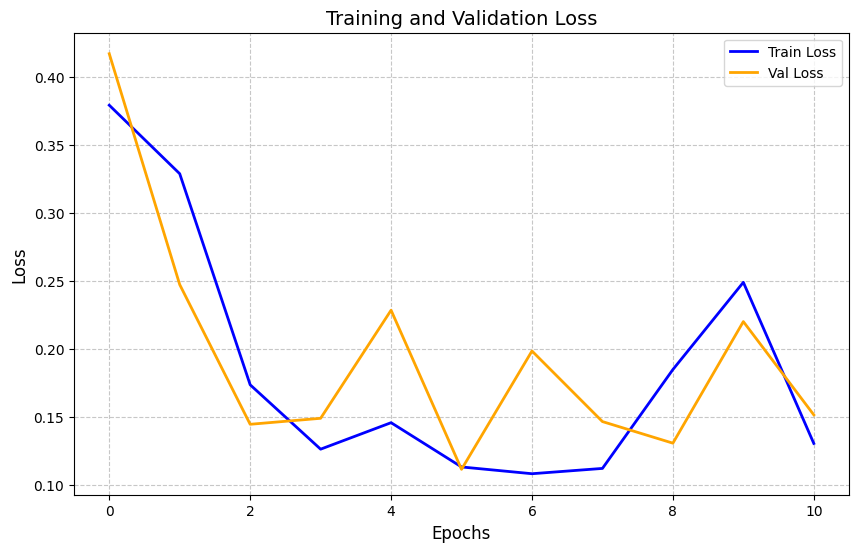

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Train Loss', color='blue', lw=2)
plt.plot(history['val_loss'], label='Val Loss', color='orange', lw=2)
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


              precision    recall  f1-score   support

       Human       0.96      0.99      0.97      9415
          AI       0.98      0.93      0.95      5585

    accuracy                           0.97     15000
   macro avg       0.97      0.96      0.96     15000
weighted avg       0.97      0.97      0.97     15000



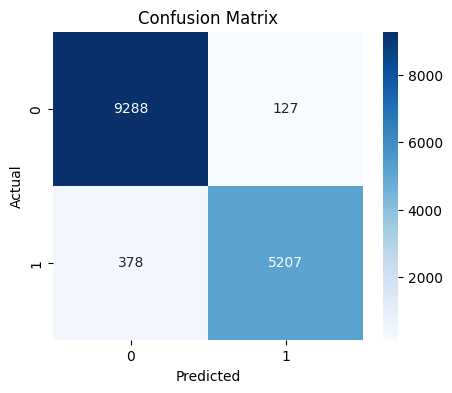

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_test_set(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            predictions = (outputs > 0.5).int().cpu().numpy()
            
            all_preds.extend(predictions)
            all_labels.extend(labels.cpu().numpy())
    
    print(classification_report(all_labels, all_preds, target_names=['Human', 'AI']))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

evaluate_test_set(rnn_model, test_loader, device)


---
### LSTM

LSTM has 3 gates and 2 memory cells

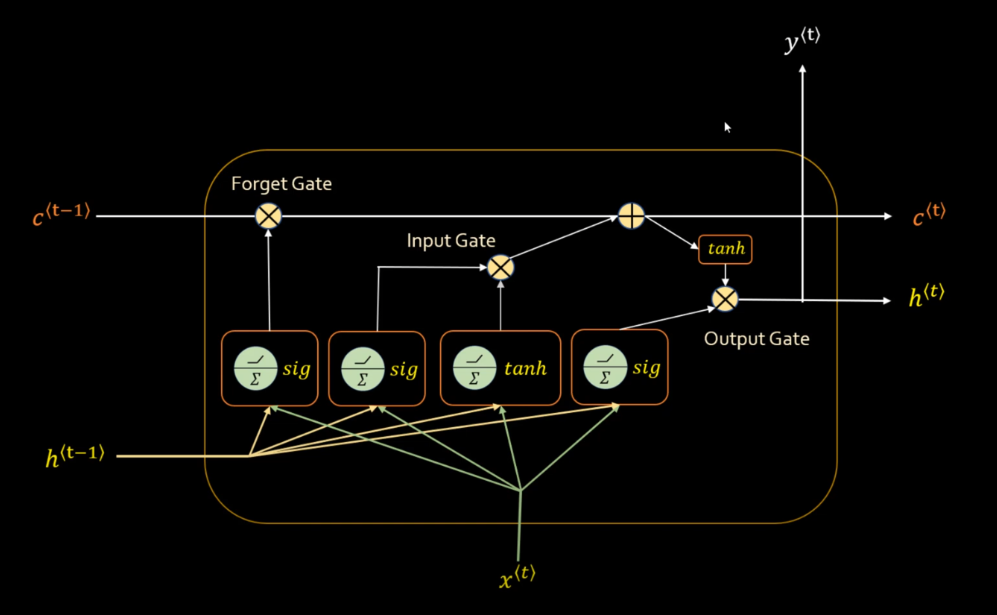

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        emb = self.embedding(x)
        # IMPORTANT: LSTM returns (output, (h_n, c_n))
        _, (hidden, cell) = self.lstm(emb)
        # We use hidden for classification
        cat_hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        return self.classifier(cat_hidden)


In [ ]:
lstm_model = LSTMModel(vocab_size=vocab_size, emb_dim=128, hidden_dim=64).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)


In [ ]:
summary(lstm_model, input_size=(1, MAX_LEN), dtypes=[torch.long], device=device)


Layer (type:depth-idx)                   Output Shape              Param #
LSTMModel                                [1, 1]                    --
├─Embedding: 1-1                         [1, 400, 128]             2,560,256
├─LSTM: 1-2                              [1, 400, 128]             99,328
├─Sequential: 1-3                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 64]                   8,256
│    └─ReLU: 2-2                         [1, 64]                   --
│    └─Linear: 2-3                       [1, 1]                    65
│    └─Sigmoid: 2-4                      [1, 1]                    --
Total params: 2,667,905
Trainable params: 2,667,905
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 42.30
Input size (MB): 0.00
Forward/backward pass size (MB): 0.82
Params size (MB): 10.67
Estimated Total Size (MB): 11.49

In [ ]:
epochs = 50
patience = 5
best_val_loss = float('inf')
early_stop_counter = 0
best_lstm_model_state = None

history = {
    'train_loss': [],
    'val_loss': []
}

for epoch in trange(epochs):
    # --- TRAINING ---
    lstm_model.train()
    train_loss_accum = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).view(-1, 1)
        
        optimizer.zero_grad()
        outputs = lstm_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss_accum += loss.item()
    
    avg_train_loss = train_loss_accum / len(train_loader)
    
    # --- VALIDATION ---
    lstm_model.eval()
    val_loss_accum = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device).view(-1, 1)
            outputs = lstm_model(inputs)
            loss = criterion(outputs, labels)
            val_loss_accum += loss.item()
            
    avg_val_loss = val_loss_accum / len(val_loader)

    # Save loss scores
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    
    print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    # --- Early stopping ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_lstm_model_state = copy.deepcopy(lstm_model.state_dict())
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
            
if best_lstm_model_state:
    lstm_model.load_state_dict(best_lstm_model_state)


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.2447 | Val Loss: 0.1185
Epoch 02 | Train Loss: 0.1035 | Val Loss: 0.0817
Epoch 03 | Train Loss: 0.0547 | Val Loss: 0.0518
Epoch 04 | Train Loss: 0.0357 | Val Loss: 0.0387
Epoch 05 | Train Loss: 0.0422 | Val Loss: 0.0311
Epoch 06 | Train Loss: 0.0218 | Val Loss: 0.0495
Epoch 07 | Train Loss: 0.0156 | Val Loss: 0.0334
Epoch 08 | Train Loss: 0.0110 | Val Loss: 0.0350
Epoch 09 | Train Loss: 0.0053 | Val Loss: 0.0303
Epoch 10 | Train Loss: 0.0053 | Val Loss: 0.0349
Epoch 11 | Train Loss: 0.0117 | Val Loss: 0.0370
Epoch 12 | Train Loss: 0.0065 | Val Loss: 0.0283
Epoch 13 | Train Loss: 0.0033 | Val Loss: 0.0239
Epoch 14 | Train Loss: 0.0026 | Val Loss: 0.0287
Epoch 15 | Train Loss: 0.0019 | Val Loss: 0.0303
Epoch 16 | Train Loss: 0.0038 | Val Loss: 0.0320
Epoch 17 | Train Loss: 0.0026 | Val Loss: 0.0268
Epoch 18 | Train Loss: 0.0027 | Val Loss: 0.0256
Early stopping triggered at epoch 18


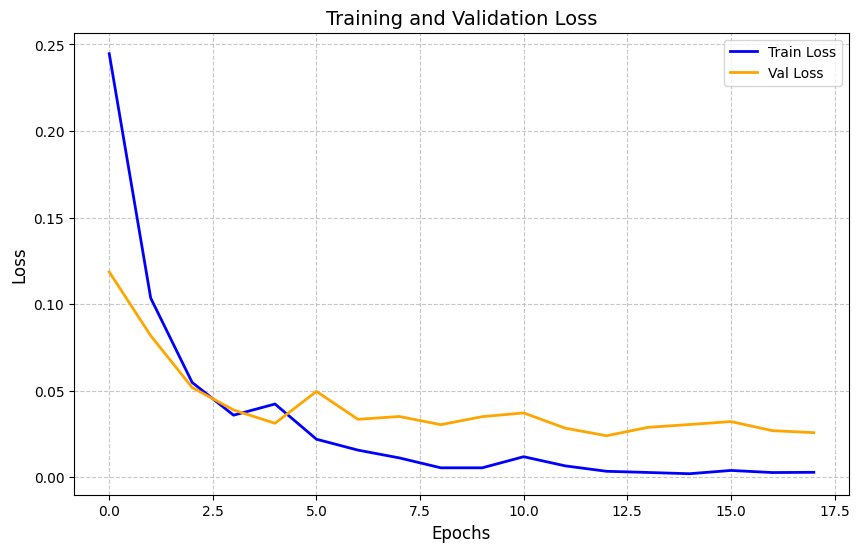

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Train Loss', color='blue', lw=2)
plt.plot(history['val_loss'], label='Val Loss', color='orange', lw=2)
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


              precision    recall  f1-score   support

       Human       0.99      1.00      0.99      9415
          AI       0.99      0.99      0.99      5585

    accuracy                           0.99     15000
   macro avg       0.99      0.99      0.99     15000
weighted avg       0.99      0.99      0.99     15000



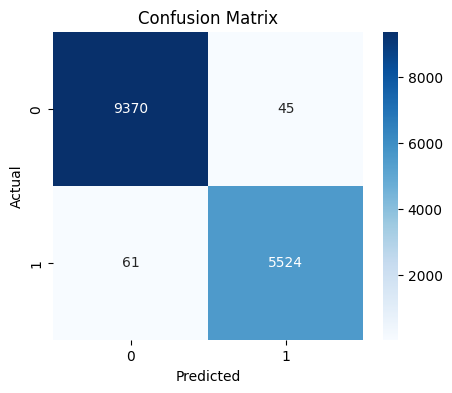

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_test_set(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            predictions = (outputs > 0.5).int().cpu().numpy()
            
            all_preds.extend(predictions)
            all_labels.extend(labels.cpu().numpy())
    
    print(classification_report(all_labels, all_preds, target_names=['Human', 'AI']))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

evaluate_test_set(lstm_model, test_loader, device)


---
### GRU

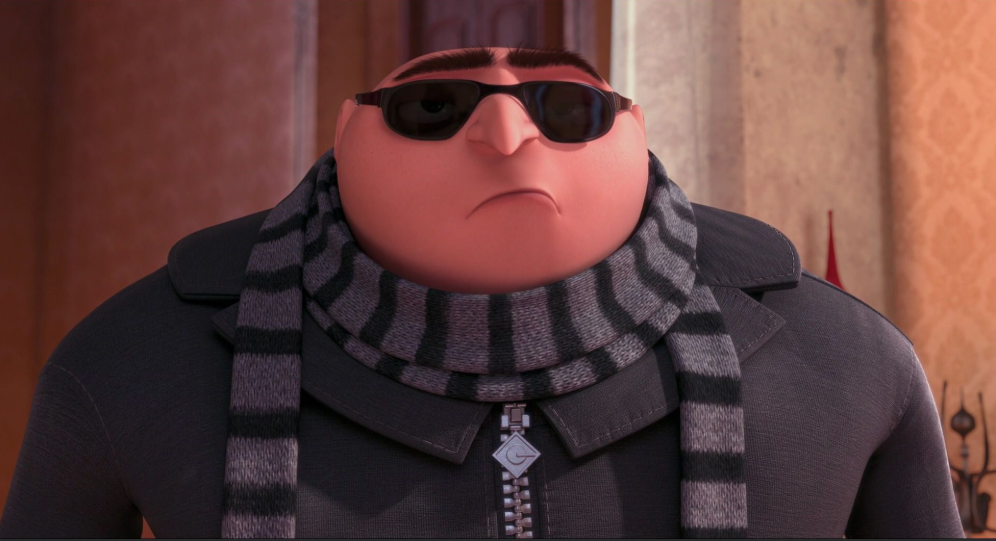

GRU has 2 gates and 1 memory cell

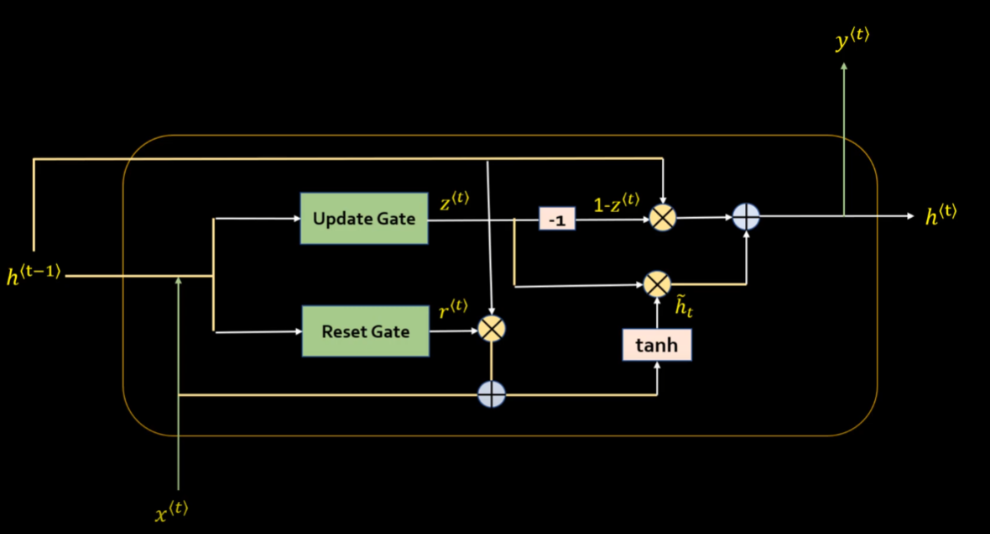

In [ ]:
class AIDetectorGRU(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super(AIDetectorGRU, self).__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        
        # Bidirectional GRU
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64), # *2 because we use bidirectional
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        emb = self.embedding(x)
        # GRU returns (output, hidden)
        _, hidden = self.gru(emb)
        
        # concatenate last hidden states of forward and backward directions
        # `hidden` has shape [num_layers * num_directions, batch, hidden_dim]
        combined_hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        
        return self.classifier(combined_hidden)


In [ ]:
model = AIDetectorGRU(vocab_size=vocab_size, emb_dim=128, hidden_dim=64).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [ ]:
summary(model, input_size=(1, MAX_LEN), dtypes=[torch.long], device=device)


Layer (type:depth-idx)                   Output Shape              Param #
AIDetectorGRU                            [1, 1]                    --
├─Embedding: 1-1                         [1, 400, 128]             2,560,256
├─GRU: 1-2                               [1, 400, 128]             74,496
├─Sequential: 1-3                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 64]                   8,256
│    └─ReLU: 2-2                         [1, 64]                   --
│    └─Dropout: 2-3                      [1, 64]                   --
│    └─Linear: 2-4                       [1, 1]                    65
│    └─Sigmoid: 2-5                      [1, 1]                    --
Total params: 2,643,073
Trainable params: 2,643,073
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 32.37
Input size (MB): 0.00
Forward/backward pass size (MB): 0.82
Params size (MB): 10.57
Estimated Total Size (MB): 11.40

In [ ]:
import copy


In [ ]:
epochs = 50
patience = 5
best_val_loss = float('inf')
early_stop_counter = 0
best_model_state = None

history = {
    'train_loss': [],
    'val_loss': []
}

for epoch in trange(epochs):
    # --- TRAINING ---
    model.train()
    train_loss_accum = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).view(-1, 1)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss_accum += loss.item()
    
    avg_train_loss = train_loss_accum / len(train_loader)
    
    # --- VALIDATION ---
    model.eval()
    val_loss_accum = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device).view(-1, 1)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss_accum += loss.item()
            
    avg_val_loss = val_loss_accum / len(val_loader)

    # Save loss scores
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    
    print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    # --- Early stopping ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
            
if best_model_state:
    model.load_state_dict(best_model_state)


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.2230 | Val Loss: 0.0913
Epoch 02 | Train Loss: 0.1103 | Val Loss: 0.0898
Epoch 03 | Train Loss: 0.0523 | Val Loss: 0.0427
Epoch 04 | Train Loss: 0.0299 | Val Loss: 0.0405
Epoch 05 | Train Loss: 0.0178 | Val Loss: 0.0310
Epoch 06 | Train Loss: 0.0091 | Val Loss: 0.0326
Epoch 07 | Train Loss: 0.0109 | Val Loss: 0.0266
Epoch 08 | Train Loss: 0.0041 | Val Loss: 0.0228
Epoch 09 | Train Loss: 0.0027 | Val Loss: 0.0414
Epoch 10 | Train Loss: 0.0036 | Val Loss: 0.0295
Epoch 11 | Train Loss: 0.0074 | Val Loss: 0.0300
Epoch 12 | Train Loss: 0.0023 | Val Loss: 0.0329
Epoch 13 | Train Loss: 0.0021 | Val Loss: 0.0387
Early stopping triggered at epoch 13


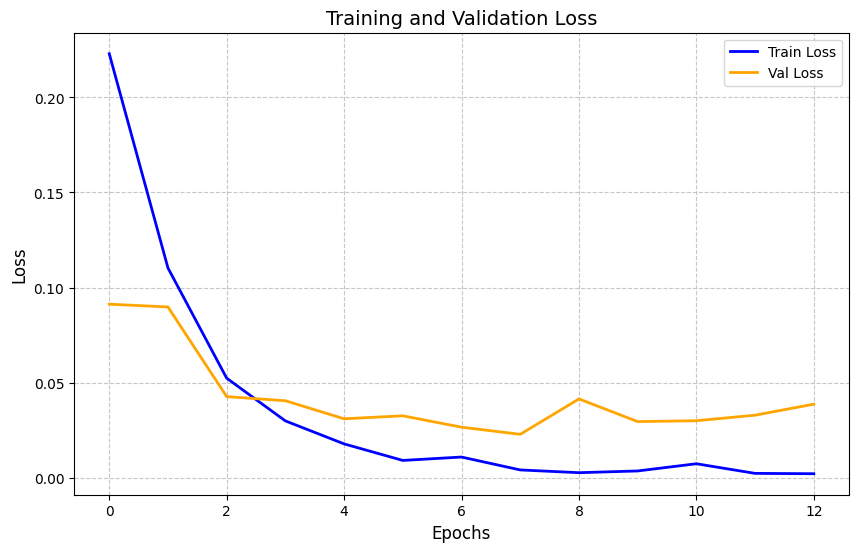

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Train Loss', color='blue', lw=2)
plt.plot(history['val_loss'], label='Val Loss', color='orange', lw=2)
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


              precision    recall  f1-score   support

       Human       0.99      1.00      1.00      9415
          AI       1.00      0.99      0.99      5585

    accuracy                           0.99     15000
   macro avg       0.99      0.99      0.99     15000
weighted avg       0.99      0.99      0.99     15000



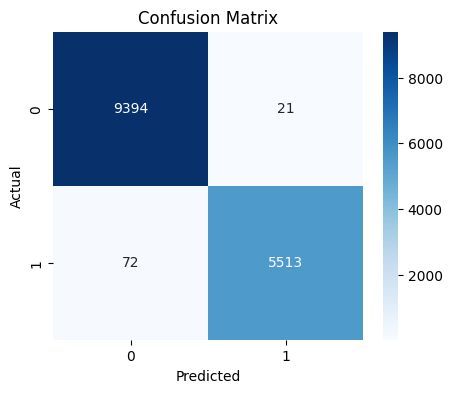

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_test_set(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            predictions = (outputs > 0.5).int().cpu().numpy()
            
            all_preds.extend(predictions)
            all_labels.extend(labels.cpu().numpy())
    
    print(classification_report(all_labels, all_preds, target_names=['Human', 'AI']))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

evaluate_test_set(model, test_loader, device)
